# Analysis

*   Descriptives



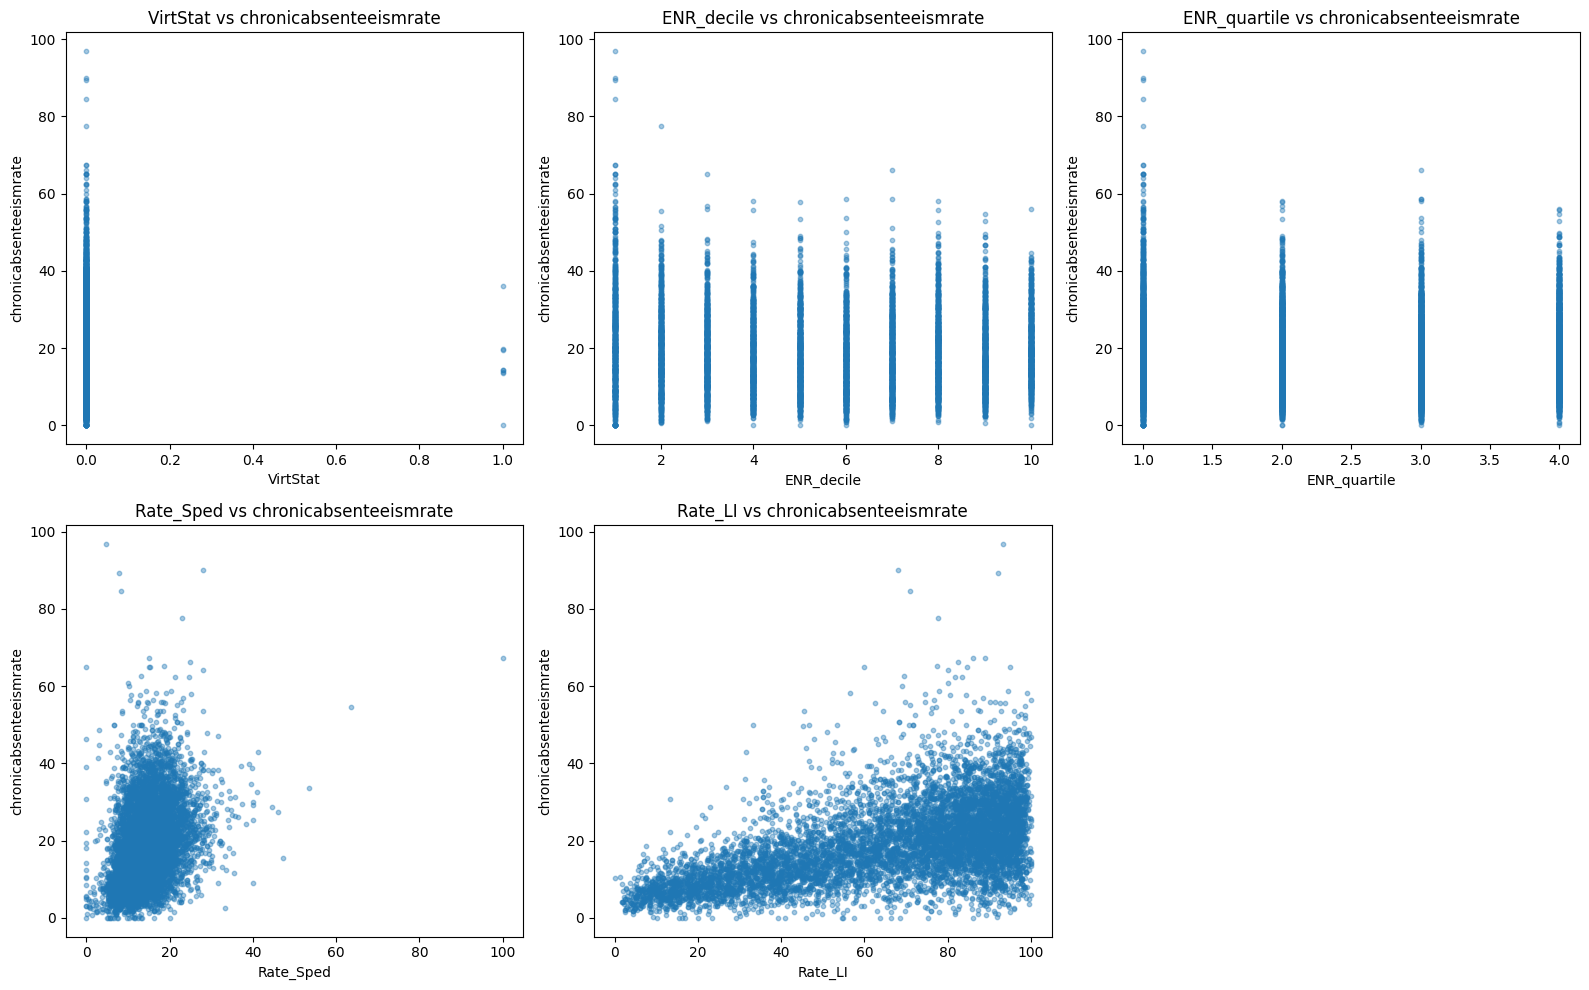

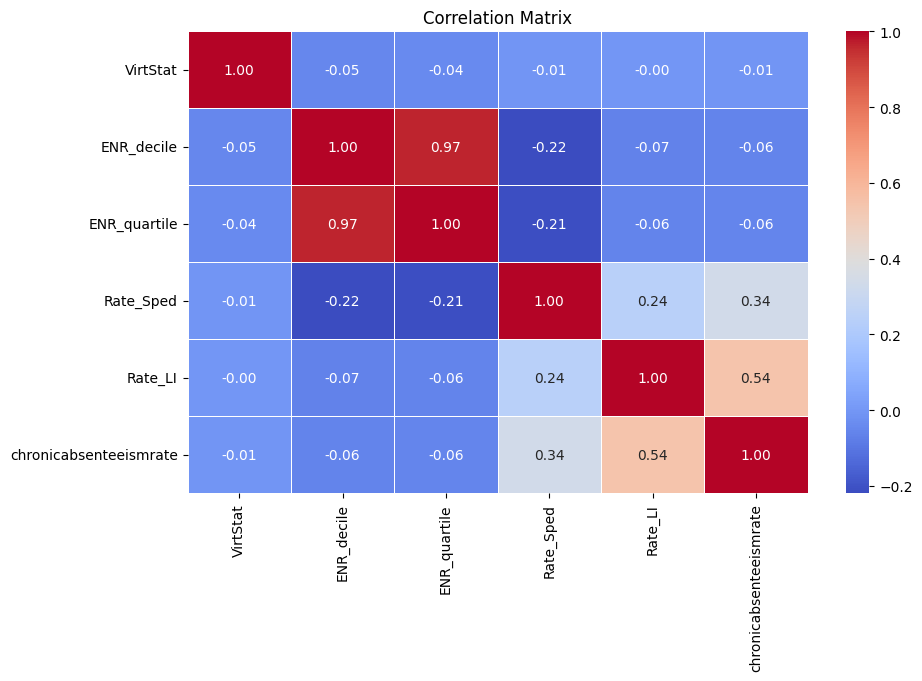

,CountyName,school_count


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

import pandas as pd

processed_path = r"C:\Users\ewpic\CA_AbsenteeismAnalysis\project\data\processed\enrollment_absenteeism_merged.csv"

df = pd.read_csv(processed_path)

target = "chronicabsenteeismrate"
predictors = ["VirtStat", "ENR_decile", "ENR_quartile", "Rate_Sped", "Rate_LI"]

n = len(predictors)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for ax, var in zip(axes, predictors):
    ax.scatter(
        df[var],
        df[target],
        alpha=0.4,
        s=10
    )
    ax.set_title(f"{var} vs {target}")
    ax.set_xlabel(var)
    ax.set_ylabel(target)

# Hide unused axes
for i in range(n, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()


#correlation

df = df.copy()

corr_vars = [
    "VirtStat",
    "ENR_decile",
    "ENR_quartile",
    "Rate_Sped",
    "Rate_LI",
    "chronicabsenteeismrate"
]

corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

# school count by county; make sure list is empty

county_counts = (
    df.groupby("CountyName")["SchoolCode"]
    .nunique()
    .reset_index(name="school_count")
)

# Sort ascending
county_counts_sorted = county_counts.sort_values("school_count", ascending=True)

# Filter counties with 4 or fewer schools
small_counties = county_counts_sorted[county_counts_sorted["school_count"] <= 4]

county_counts_sorted,

small_counties

# Multi-Level Model

In [7]:
import pandas as pd
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 1. Inspect dtypes
# ---------------------------------------------------------
print(df.dtypes)


# ---------------------------------------------------------
# 2. Fix column types for MixedLM
# ---------------------------------------------------------

# Grouping variable MUST be categorical
df["CountyName"] = df["CountyName"].astype("category")

# Predictors stored as Int64 → convert to float
df["VirtStat"] = df["VirtStat"].astype(float)
df["ENR_decile"] = df["ENR_decile"].astype(float)
df["ENR_quartile"] = df["ENR_quartile"].astype(float)

# SOC is int64 → convert to categorical
df["SOC"] = df["SOC"].astype("category")

# ChronicAbsenteeismCount is already float64 in your processed file
# but we ensure it's numeric just in case
df["ChronicAbsenteeismCount"] = pd.to_numeric(df["ChronicAbsenteeismCount"], errors="coerce")

# ---------------------------------------------------------
# 3. Drop rows with missing model variables and reset index
# ---------------------------------------------------------
model_vars = [
    "chronicabsenteeismrate", "VirtStat", "ENR_decile", "SOC",
    "Rate_Sped", "Rate_LI", "CountyName"
]

model_df = df[model_vars].dropna().reset_index(drop=True)

# ---------------------------------------------------------
# 4. Fit the MixedLM model
# ---------------------------------------------------------
model = smf.mixedlm(
    "chronicabsenteeismrate ~ VirtStat + ENR_decile + SOC + Rate_Sped + Rate_LI",
    model_df,
    groups=model_df["CountyName"]
).fit()

print(model.summary())

# Extract variance components
group_var = model.cov_re.iloc[0, 0]      # random intercept variance
residual_var = model.scale               # residual variance

# Compute ICC
icc = group_var / (group_var + residual_var)

print("Intraclass Correlation (ICC):", icc)

# Extract random effects robustly
re_df = pd.DataFrame(model.random_effects).T

# If the column is named "Group", rename it
if "Group" in re_df.columns:
    re_df = re_df.rename(columns={"Group": "random_intercept"})

# If the column is numeric index 0, rename that
elif 0 in re_df.columns:
    re_df = re_df.rename(columns={0: "random_intercept"})

# Sort
re_df = re_df.sort_values("random_intercept")

re_df

SchoolCode                    int64
SchoolName                      str
DistrictCode                  int64
CountyName                 category
District                        str
GSserved                        str
Virtual                         str
SOC                        category
VirtStat                    float64
TA                          float64
SG_SD                       float64
SG_DS                       float64
ChronicAbsenteeismCount     float64
chronicabsenteeismrate      float64
Cnty_Sch_Cnt                  int64
ENR_decile                  float64
ENR_quartile                float64
Rate_Sped                   float64
Rate_LI                     float64
dtype: object
               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: chronicabsenteeismrate
No. Observations: 7858    Method:             REML                  
No. Groups:       56      Scale:              56.4197               
Min. group size:  7       Log-Likelihood: 

,random_intercept
Colusa,-9.072801
Kings,-8.242396
Tulare,-6.697675
Modoc,-6.455733
Glenn,-6.308497
Orange,-5.685140
Monterey,-5.572403
Trinity,-5.398315
Santa Barbara,-5.386161
Tehama,-5.265129


# Calculate Residuals and Identify High Performers and Low Performers

In [8]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 0. Ensure SchoolCode is included in model_df
# ---------------------------------------------------------
model_df = df[
    [
        "SchoolCode",
        "chronicabsenteeismrate",
        "VirtStat",
        "ENR_decile",
        "SOC",
        "Rate_Sped",
        "Rate_LI",
        "CountyName"
    ]
].dropna().reset_index(drop=True)

# ---------------------------------------------------------
# 1. Add predictions to the modeling dataframe
# ---------------------------------------------------------
model_df["predicted"] = model.predict()

# ---------------------------------------------------------
# 2. Compute residuals and standardized residuals
# ---------------------------------------------------------
model_df["residual"] = model_df["chronicabsenteeismrate"] - model_df["predicted"]
resid_sd = model_df["residual"].std()
model_df["residual_z"] = model_df["residual"] / resid_sd

# ---------------------------------------------------------
# 3. Merge predictions/residuals back to full dataset
# ---------------------------------------------------------
merged = df.merge(
    model_df[["SchoolCode", "predicted", "residual", "residual_z"]],
    on="SchoolCode",
    how="left"
)

# ---------------------------------------------------------
# 4. Identify outlier schools using ±2.5 SD
# ---------------------------------------------------------
high_outliers = merged[merged["residual_z"] > 2.5]
low_outliers  = merged[merged["residual_z"] < -2.5]

# ---------------------------------------------------------
# 5. Display results with school + district + LI + SPED
# ---------------------------------------------------------
cols_to_show = [
    "SchoolName", "District", "CountyName",
    "Rate_LI", "Rate_Sped",
    "chronicabsenteeismrate", "predicted",
    "residual", "residual_z"
]

print("Schools MORE than 2.5 SD ABOVE predicted absenteeism rate:")
display(high_outliers[cols_to_show].sort_values("residual_z", ascending=False))

print("\nSchools MORE than 2.5 SD BELOW predicted absenteeism rate:")
display(low_outliers[cols_to_show].sort_values("residual_z"))

import os

processed_path = r"C:\Users\ewpic\CA_AbsenteeismAnalysis\project\data\processed"

# Ensure folder exists
os.makedirs(processed_path, exist_ok=True)

high_path = os.path.join(processed_path, "high_absenteeism_outliers_2_5sd.csv")
low_path  = os.path.join(processed_path, "low_absenteeism_outliers_2_5sd.csv")

high_outliers[cols_to_show].to_csv(high_path, index=False)
low_outliers[cols_to_show].to_csv(low_path, index=False)

print("Saved high outliers to:", high_path)
print("Saved low outliers to:", low_path)

Schools MORE than 2.5 SD ABOVE predicted absenteeism rate:


,SchoolName,District,CountyName,Rate_LI,Rate_Sped,chronicabsenteeismrate,predicted,residual,residual_z
582,Stockton High,Stockton Unified,San Joaquin,93.193717,4.712042,96.9,27.543293,69.356707,8.504143
78,Weitchpec Elementary,Klamath-Trinity Joint Unified,Humboldt,70.833333,8.333333,84.6,18.840303,65.759697,8.063097
158,Thurgood Marshall,Compton Unified,Los Angeles,92.156863,7.843137,89.3,28.981945,60.318055,7.395872
82,Palisade Glacier High (Continuation),Bishop Union Elementary,Inyo,68.000000,28.000000,90.0,31.369056,58.630944,7.189008
969,Hoopa Valley High,Klamath-Trinity Joint Unified,Humboldt,77.735849,23.018868,77.5,31.332226,46.167774,5.660842
...,...,...,...,...,...,...,...,...,...
3884,Hacienda Elementary,Mojave Unified,Kern,84.909457,19.114688,46.0,25.466791,20.533209,2.517671
2754,Blanche Charles Elementary,Calexico Unified,Imperial,92.124105,18.615752,47.4,26.885794,20.514206,2.515341
7051,Susan Miller Dorsey Senior High,Los Angeles Unified,Los Angeles,97.538101,17.233294,52.8,32.355235,20.444765,2.506826
6615,Greer Elementary,San Juan Unified,Sacramento,82.283465,11.154856,41.9,21.475952,20.424048,2.504286



Schools MORE than 2.5 SD BELOW predicted absenteeism rate:


,SchoolName,District,CountyName,Rate_LI,Rate_Sped,chronicabsenteeismrate,predicted,residual,residual_z
231,Walton Middle,Compton Unified,Los Angeles,95.833333,33.333333,2.5,34.929901,-32.429901,-3.976378
1129,Bunche Middle,Compton Unified,Los Angeles,95.104895,17.132867,1.5,28.369554,-26.869554,-3.294599
296,Warner Junior/Senior High,Warner Unified,San Diego,71.428571,27.551020,5.9,31.904706,-26.004706,-3.188556
514,Pond Elementary,Pond Union Elementary,Kern,96.000000,14.857143,2.2,27.671922,-25.471922,-3.123229
255,Burnt Ranch Elementary,Burnt Ranch Elementary,Trinity,75.294118,20.000000,0.0,25.381137,-25.381137,-3.112097
536,Enterprise Middle,Compton Unified,Los Angeles,91.208791,23.076923,4.9,29.989596,-25.089596,-3.076350
4216,Davis Middle,Compton Unified,Los Angeles,91.923077,11.346154,0.2,25.107454,-24.907454,-3.054017
358,Maxwell Sr High,Maxwell Unified,Colusa,76.068376,17.094017,4.2,28.804981,-24.604981,-3.016929
4276,Riverside Virtual,Riverside Unified,Riverside,85.877863,20.419847,7.7,31.971696,-24.271696,-2.976064
3332,Rosecrans Elementary,Compton Unified,Los Angeles,94.771242,16.993464,2.8,26.804018,-24.004018,-2.943242


Saved high outliers to: C:\Users\ewpic\CA_AbsenteeismAnalysis\project\data\processed\high_absenteeism_outliers_2_5sd.csv
Saved low outliers to: C:\Users\ewpic\CA_AbsenteeismAnalysis\project\data\processed\low_absenteeism_outliers_2_5sd.csv
